In [1]:
import pandas as pd
import numpy as np
import random
from datetime import timedelta, date

# 1. Setup the parameters
np.random.seed(42)
num_records = 500
campaigns = ['Project Education', 'Winter Clothes Drive', 'Feed the Hungry', 'Women Empowerment']
channels = ['WhatsApp', 'LinkedIn', 'Instagram', 'Cold Call']
volunteers = [f'V{str(i).zfill(3)}' for i in range(1, 11)] # V001 to V010
statuses = ['Completed', 'Completed', 'Completed', 'Pending', 'Failed'] # Weighted to mostly completed

# Generate random dates over the last 6 months
start_date = date.today() - timedelta(days=180)
dates = [start_date + timedelta(days=random.randint(0, 180)) for _ in range(num_records)]

# Generate the data
data = {
    'Date': dates,
    'Campaign Name': np.random.choice(campaigns, num_records),
    'Volunteer ID': np.random.choice(volunteers, num_records),
    'Donor Channel': np.random.choice(channels, num_records, p=[0.4, 0.2, 0.3, 0.1]),
    'Amount Raised (INR)': np.random.randint(50, 5000, num_records),
    'Donation Status': np.random.choice(statuses, num_records)
}

df = pd.DataFrame(data)

# Add a target amount based on the campaign (just for realistic comparison)
target_dict = {'Project Education': 500000, 'Winter Clothes Drive': 200000, 'Feed the Hungry': 300000, 'Women Empowerment': 400000}
df['Campaign Target (INR)'] = df['Campaign Name'].map(target_dict)

# Save to CSV
df.to_csv('NayePankh_Fundraising_Data.csv', index=False)
print("✅ Dataset 'NayePankh_Fundraising_Data.csv' created successfully!")
print(df.head())

✅ Dataset 'NayePankh_Fundraising_Data.csv' created successfully!
         Date      Campaign Name Volunteer ID Donor Channel  \
0  2026-01-24    Feed the Hungry         V005      LinkedIn   
1  2026-03-14  Women Empowerment         V007      WhatsApp   
2  2026-05-09  Project Education         V001     Instagram   
3  2025-12-21    Feed the Hungry         V003      LinkedIn   
4  2026-03-18    Feed the Hungry         V002      LinkedIn   

   Amount Raised (INR) Donation Status  Campaign Target (INR)  
0                 2433       Completed                 300000  
1                 3289         Pending                 400000  
2                 2189          Failed                 500000  
3                 1754       Completed                 300000  
4                  412       Completed                 300000  


/tmp/ipykernel_512/4277939816.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=campaign_sums, x='Amount Raised (INR)', y='Campaign Name', palette='viridis')
/tmp/ipykernel_512/4277939816.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volunteer_sums.values, y=volunteer_sums.index, palette='magma')


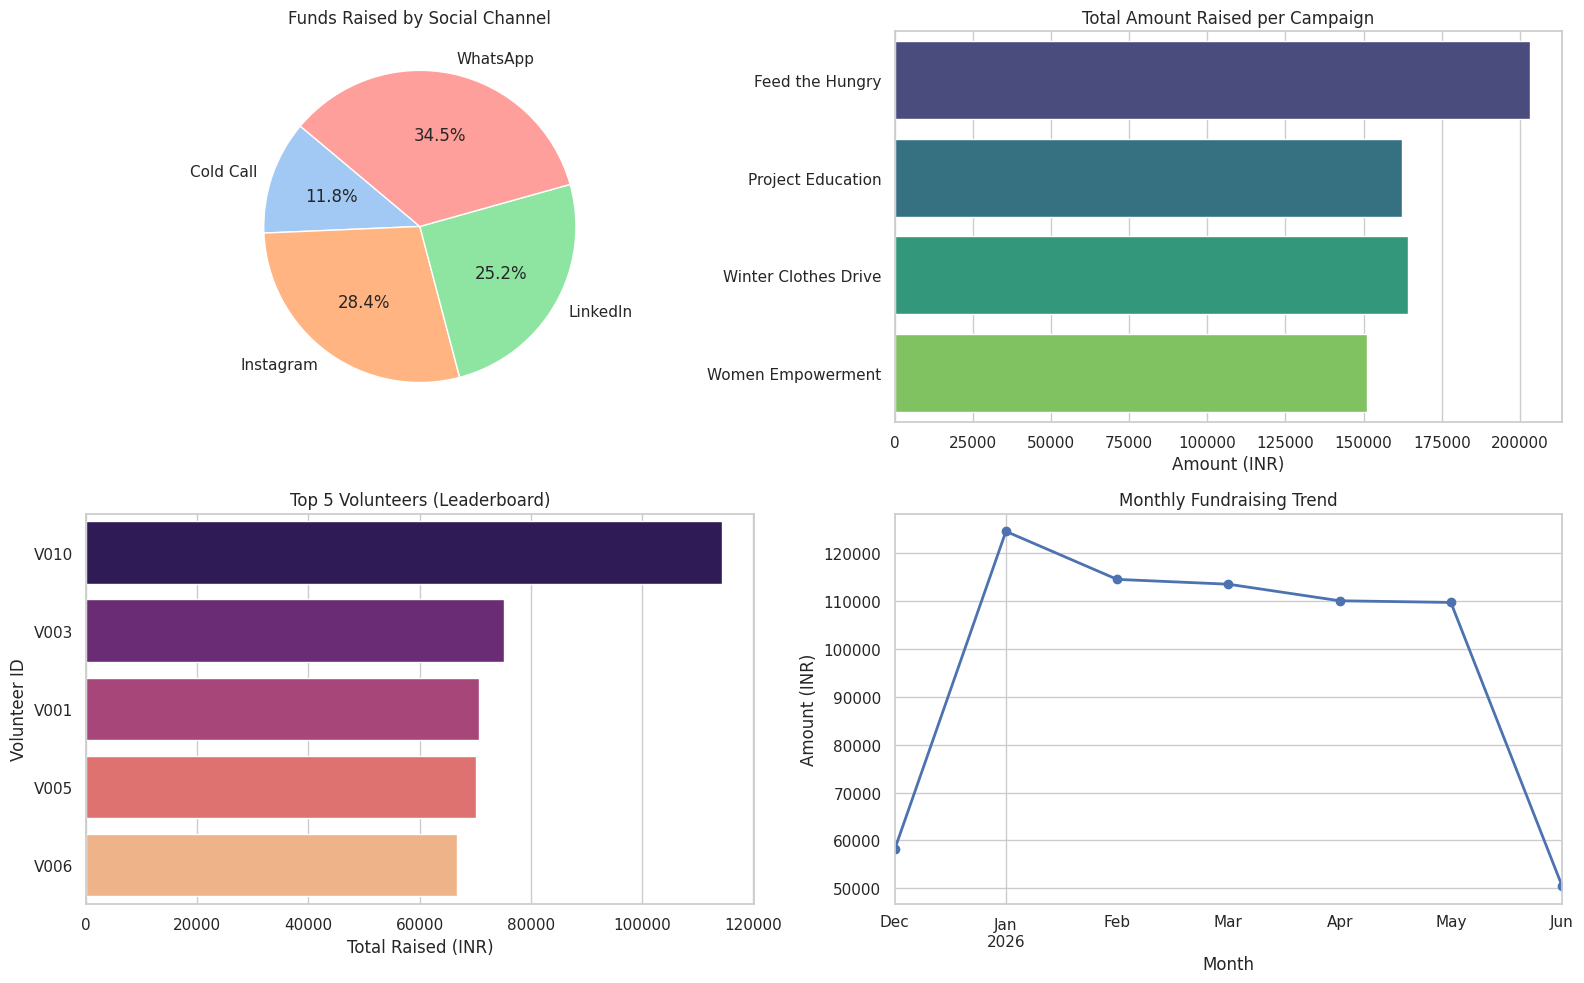

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only completed donations for revenue analysis
completed_df = df[df['Donation Status'] == 'Completed']

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# --- Visualization 1: Donations by Channel (Pie Chart) ---
plt.subplot(2, 2, 1)
channel_sums = completed_df.groupby('Donor Channel')['Amount Raised (INR)'].sum()
plt.pie(channel_sums, labels=channel_sums.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Funds Raised by Social Channel')

# --- Visualization 2: Campaign Performance (Bar Chart) ---
plt.subplot(2, 2, 2)
campaign_sums = completed_df.groupby('Campaign Name')['Amount Raised (INR)'].sum().reset_index()
sns.barplot(data=campaign_sums, x='Amount Raised (INR)', y='Campaign Name', palette='viridis')
plt.title('Total Amount Raised per Campaign')
plt.xlabel('Amount (INR)')
plt.ylabel('')

# --- Visualization 3: Volunteer Leaderboard ---
plt.subplot(2, 2, 3)
volunteer_sums = completed_df.groupby('Volunteer ID')['Amount Raised (INR)'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=volunteer_sums.values, y=volunteer_sums.index, palette='magma')
plt.title('Top 5 Volunteers (Leaderboard)')
plt.xlabel('Total Raised (INR)')
plt.ylabel('Volunteer ID')

# --- Visualization 4: Daily Donation Trend ---
plt.subplot(2, 2, 4)
daily_trend = completed_df.groupby('Date')['Amount Raised (INR)'].sum().reset_index()
# Group by month for a smoother line
daily_trend['Month'] = pd.to_datetime(daily_trend['Date']).dt.to_period('M')
monthly_trend = daily_trend.groupby('Month')['Amount Raised (INR)'].sum()
monthly_trend.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Monthly Fundraising Trend')
plt.xlabel('Month')
plt.ylabel('Amount (INR)')

plt.tight_layout()
plt.show()

In [3]:
# Calculate KPIs
total_raised = completed_df['Amount Raised (INR)'].sum()
total_donations = len(completed_df)
avg_donation = completed_df['Amount Raised (INR)'].mean()
success_rate = (len(completed_df) / len(df)) * 100

best_channel = channel_sums.idxmax()
top_volunteer = volunteer_sums.index[0]

# Generate the Automated Report string
automated_report = f"""
==================================================
  NAYEPANKH FOUNDATION - WEEKLY AUTOMATED REPORT
==================================================
Generated on: {date.today()}

📊 HIGH-LEVEL KPIs:
- Total Funds Raised: INR {total_raised:,.2f}
- Total Successful Donations: {total_donations}
- Average Donation Size: INR {avg_donation:,.2f}
- Transaction Success Rate: {success_rate:.1f}%

🏆 TOP PERFORMERS:
- Top Volunteer: {top_volunteer} (Raised INR {volunteer_sums.iloc[0]:,.2f})
- Most Effective Channel: {best_channel} (Accounted for {(channel_sums.max()/total_raised)*100:.1f}% of funds)

📈 ACTIONABLE INSIGHTS:
1. {best_channel} is your most profitable outreach method. Consider doubling the volunteer focus there.
2. The transaction success rate is {success_rate:.1f}%. If this is below 70%, investigate potential payment gateway failures for 'Pending' donations.

==================================================
*Report generated automatically via Python Analytics*
"""

print(automated_report)

# Optional: Save it to a text file automatically
with open('NayePankh_Weekly_Report.txt', 'w') as f:
    f.write(automated_report)


  NAYEPANKH FOUNDATION - WEEKLY AUTOMATED REPORT
Generated on: 2026-06-14

📊 HIGH-LEVEL KPIs:
- Total Funds Raised: INR 680,778.00
- Total Successful Donations: 280
- Average Donation Size: INR 2,431.35
- Transaction Success Rate: 56.0%

🏆 TOP PERFORMERS:
- Top Volunteer: V010 (Raised INR 114,342.00)
- Most Effective Channel: WhatsApp (Accounted for 34.5% of funds)

📈 ACTIONABLE INSIGHTS:
1. WhatsApp is your most profitable outreach method. Consider doubling the volunteer focus there.
2. The transaction success rate is 56.0%. If this is below 70%, investigate potential payment gateway failures for 'Pending' donations.

*Report generated automatically via Python Analytics*

